In [1]:
import numpy as np
import pandas as pd
import os
import sys
sys.path.append('/home/v-zhaoyang2/project/DNADesign/regLM/src')
from plotnine import *
import reglm.regression

sys.path.append('../../')
import scripts.viz, scripts.utils

/home/v-zhaoyang2/anaconda3/envs/reglm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
train = scripts.utils.load_csv('../01_data_processing/lm_data/train.csv')
val = scripts.utils.load_csv('../01_data_processing/lm_data/val.csv')
# test = scripts.utils.load_csv('../01_data_processing/lm_data/test.csv')

test = scripts.utils.load_csv('../01_data_processing/regression_separate_data/train.csv')

In [3]:
train

,Sequence,HepG2_mean,K562_mean,SKNSH_mean,chr,len,label,h_token,k_token,s_token
enh_1,CATAAAGATGAGGCTTGGCAAAGAACATCTCTCGGTGCCTCCCATT...,0.004565,0.379639,-0.244395,1,200,010,0,1,0
enh_2,CATAAAGCCAATCACTGAGATGACAAGTACTGCCAGGAAAGAAGGC...,0.384537,0.036707,-0.004578,1,200,100,1,0,0
enh_4,CATAAAGGCAGTGTAGACCCAAACAGTGAGCAGTAGCAAGATTTAT...,4.116494,4.508784,3.040183,15,200,333,3,3,3
enh_5,CATAAAGGGCTGAACATGCTGTTGAAAAAATGTAGATATAAAAGTT...,1.423444,1.616602,1.335892,12,200,222,2,2,2
enh_6,CATAAAGGGCTGAACATGCTGTTGAAAAAATGTAGATATAAAAGTT...,1.444247,1.454357,0.958289,12,200,222,2,2,2
...,...,...,...,...,...,...,...,...,...,...
enh_798059,CAGTAGTAAGAAAGAGACAATGCAAAGGAATTGGCACAGCACTCAG...,5.344297,7.443810,6.585129,4,200,333,3,3,3
enh_798060,CAGTACTGCTGGCCCCAGAAAAGCCCCTCTCCTTATACCCTAGGCC...,-0.156933,-0.204913,-0.209358,18,200,000,0,0,0
enh_798061,CAGTACCTTGTCCCCACTTCCCATTTGGCCTCTGGCAGAGGAGGAG...,0.613623,1.218233,0.569894,12,200,121,1,2,1
enh_798062,CAGTACACCCCAGCTTCCAAAGGCCTTCTGTGACAAAGAGAGACTA...,-0.338764,-0.222234,-0.817852,3,200,000,0,0,0


In [ ]:
# random select 50% as data to train the surrogate model

train_surrogate = train.sample(frac=0.5, random_state=42)
# only keep HepG2_mean below 95 percentile
exp_sep = train_surrogate.HepG2_mean.quantile(0.95)
print(exp_sep)
train_surrogate = train_surrogate[train_surrogate.HepG2_mean < exp_sep]

val_surrogate = val.sample(frac=0.5, random_state=42)
val_surrogate = val_surrogate[val_surrogate.HepG2_mean < exp_sep]


test_surrogate = test.sample(frac=0.5, random_state=42)
test_surrogate = test_surrogate[test_surrogate.HepG2_mean < exp_sep]

import os
os.makedirs('/home/v-zhaoyang2/project/DNADesign/regLM/human_enhancers/01_data_processing/surrogate_data', exist_ok=True)

# train_surrogate.to_csv('/home/v-zhaoyang2/project/DNADesign/regLM/human_enhancers/01_data_processing/surrogate_data/train_hepg2.csv')
# val_surrogate.to_csv('/home/v-zhaoyang2/project/DNADesign/regLM/human_enhancers/01_data_processing/surrogate_data/val_hepg2.csv')
# test_surrogate.to_csv('/home/v-zhaoyang2/project/DNADesign/regLM/human_enhancers/01_data_processing/surrogate_data/test_hepg2.csv')



2.5864180027212433


In [7]:
train_ds = reglm.regression.SeqDataset(train_surrogate[['Sequence', 'HepG2_mean']])
val_ds = reglm.regression.SeqDataset(val_surrogate[['Sequence', 'HepG2_mean']])

In [8]:
model = reglm.regression.EnformerModel(lr=1e-4, loss='mse', pretrained=True)

/home/v-zhaoyang2/anaconda3/envs/reglm/lib/python3.8/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
/home/v-zhaoyang2/anaconda3/envs/reglm/lib/python3.8/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()


In [9]:
# weights = 1/train.label.value_counts()[train.label]
# weights = (weights/weights.sum()).tolist()
weights = 1/train_surrogate.label.value_counts()[train_surrogate.label]
weights = (weights/weights.sum()).tolist()

In [22]:
trainer = model.train_on_dataset(
    train_ds, val_ds, batch_size=1024, num_workers=16, device=0, weights=weights)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params
-------------------------------------
0 | trunk | Sequential | 229 M 
1 | head  | Linear     | 3.1 K 
2 | loss  | MSELoss    | 0     
-------------------------------------
229 M     Trainable params
0         Non-trainable params
229 M     Total params
919.394   Total estimated model params size (MB)


Sanity Checking DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  9.96it/s]
val_loss 0.12210556119680405
Epoch 0: 100%|██████████| 312/312 [01:24<00:00,  3.68it/s, loss=0.376, v_num=3, train_loss_step=0.404]
val_loss 0.15679161250591278
Epoch 1: 100%|██████████| 312/312 [01:35<00:00,  3.25it/s, loss=0.265, v_num=3, train_loss_step=0.291, train_loss_epoch=0.589]
val_loss 0.16475360095500946
Epoch 2: 100%|██████████| 312/312 [01:27<00:00,  3.56it/s, loss=0.215, v_num=3, train_loss_step=0.237, train_loss_epoch=0.303]
val_loss 0.18765030801296234
Epoch 3: 100%|██████████| 312/312 [01:27<00:00,  3.56it/s, loss=0.182, v_num=3, train_loss_step=0.207, train_loss_epoch=0.234]
val_loss 0.20860256254673004
Epoch 4: 100%|██████████| 312/312 [02:06<00:00,  2.47it/s, loss=0.159, v_num=3, train_loss_step=0.189, train_loss_epoch=0.194]
val_loss 0.22999249398708344
Epoch 5: 100%|██████████| 312/312 [01:36<00:00,  3.22it/s, loss=0.145, v_num=3, train_loss_step=0.164, train_loss_epoch=0.167]
val_loss 0.1

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 312/312 [01:35<00:00,  3.26it/s, loss=0.0986, v_num=3, train_loss_step=0.0952, train_loss_epoch=0.100]


In [23]:
!mv {trainer.checkpoint_callback.best_model_path} human_regression_paired_hepg2_mbo.ckpt

In [17]:
model = reglm.regression.EnformerModel.load_from_checkpoint(
    # 'human_regression_paired_hepg2_mbo.ckpt'
    "/home/v-zhaoyang2/project/DNADesign/regLM/human_enhancers/02_regression_paired/human_regression_paired_hepg2.ckpt"
)

/home/v-zhaoyang2/anaconda3/envs/reglm/lib/python3.8/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.


In [22]:
test = scripts.utils.load_csv(
    '../01_data_processing/regression_separate_data/train.csv')
print(len(test))

test = test[test.HepG2_mean < exp_sep]
# test_ds = reglm.regression.SeqDataset(test_surrogate.Sequence.tolist())
# print(f"len of test_ds: {len(test_ds)}")
# print(f"len of test_surrogate: {len(test_surrogate)}")
# test_surrogate['paired_pred_hepg2'] = model.predict_on_dataset(
#     test_ds, device=0, batch_size=1024, num_workers=4)

test_ds = reglm.regression.SeqDataset(test[['Sequence', 'HepG2_mean']])
test['paired_pred_hepg2'] = model.predict_on_dataset(
    test_ds, device=0, batch_size=1024, num_workers=4)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


83868
Predicting DataLoader 0: 100%|██████████| 78/78 [00:07<00:00, 11.06it/s]


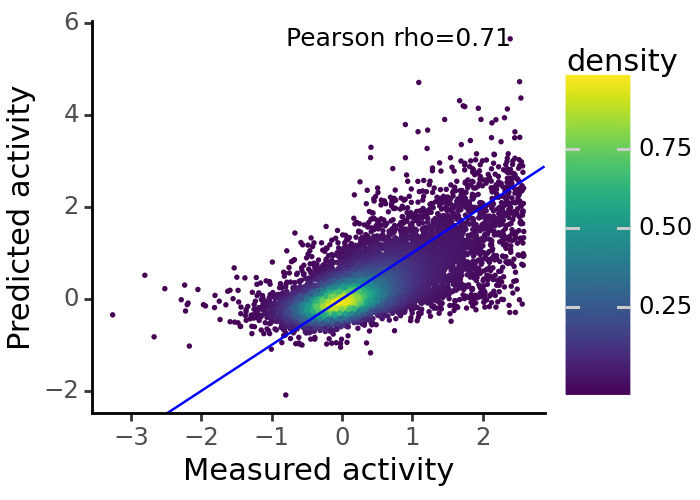

<Figure Size: (350 x 250)>

In [23]:
# p = scripts.viz.pointdensityplot(
#     test_surrogate.sample(10000), true_col='HepG2_mean', pred_col='paired_pred_hepg2',
#     corrx=0.8) + theme(figure_size=(3.5, 2.5))
p = scripts.viz.pointdensityplot(
    test.sample(10000), true_col='HepG2_mean', pred_col='paired_pred_hepg2',
    corrx=0.8) + theme(figure_size=(3.5, 2.5))

p